# Medical Billing Research Project
## 03f — XGBoost Model

**Loads from:** ../dataset/train_set.csv
**Evaluates on:** ../dataset/test_set.csv
**Target variable:** Processing Class (Timely / Delayed)
**Predictors:** 6 categorical variables

### Objective
Build an XGBoost (Extreme Gradient Boosting) classification
model as suggested by the supervisor. XGBoost is a powerful
gradient boosting ensemble method that often outperforms
Random Forest on tabular data. It builds trees sequentially
where each tree corrects the errors of the previous one,
using gradient descent optimisation.

We compare XGBoost performance against the previously
selected Random Forest model to determine whether the
additional complexity yields meaningful improvement.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND LOAD DATA
# XGBoost requires numeric input like other scikit-learn
# compatible models. We apply One-Hot Encoding the same
# way we did for the other models to keep results comparable.
# XGBoost does not require feature scaling as it uses
# gradient-based tree splits not distance calculations.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, f1_score
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load data ─────────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

# ── One-Hot Encoding (identical to other models) ──────────
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

# Encode target — Delayed = 1, Timely = 0
y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

print("=" * 60)
print("DATA LOADED AND ENCODED — XGBOOST")
print("=" * 60)
print(f"  Training records  : {len(X_train_enc):,}")
print(f"  Test records      : {len(X_test_enc):,}")
print(f"  Encoded columns   : {X_train_enc.shape[1]}")
print(f"  Columns match     : "
      f"{list(X_train_enc.columns) == list(X_test_enc.columns)}")
print(f"\n  Training target:")
print(f"    Delayed = 1 : {y_train_enc.sum():,}")
print(f"    Timely  = 0 : {(y_train_enc==0).sum():,}")

DATA LOADED AND ENCODED — XGBOOST
  Training records  : 35,000
  Test records      : 15,000
  Encoded columns   : 43
  Columns match     : True

  Training target:
    Delayed = 1 : 8,427
    Timely  = 0 : 26,573


In [2]:
# ============================================================
# CELL 2: FIT XGBOOST MODEL
# XGBoost is short for eXtreme Gradient Boosting.
# Unlike Random Forest which builds 500 trees independently
# and averages their votes, XGBoost builds trees sequentially
# where each new tree corrects the mistakes of the previous
# tree. It uses gradient descent to minimise prediction error.
#
# Key parameters explained:
# n_estimators=500 — Number of boosting rounds (trees).
#   Same as Random Forest for fair comparison.
# learning_rate=0.1 — How much each tree contributes to
#   the final prediction. Lower values = more conservative
#   updates = better generalisation but slower convergence.
# max_depth=6 — Maximum depth of each tree. XGBoost trees
#   are typically shallower than Random Forest trees as
#   the boosting process accumulates depth across trees.
# scale_pos_weight — XGBoost's equivalent of class_weight.
#   Calculated as ratio of negative to positive class.
#   This upweights the minority Delayed class during training.
# random_state=42 — Reproducibility seed.
# use_label_encoder=False, eval_metric='logloss' — These
#   suppress warnings from newer XGBoost versions about
#   default behaviour changes.
# ============================================================

# Calculate scale_pos_weight for class balancing
# This is the XGBoost way of handling class imbalance
# Formula: (number of negative class) / (number of positive class)
n_negative = (y_train_enc == 0).sum()
n_positive = (y_train_enc == 1).sum()
scale_pos_weight = n_negative / n_positive

print("=" * 60)
print("XGBOOST — MODEL CONFIGURATION")
print("=" * 60)
print(f"  scale_pos_weight calculation:")
print(f"    Negative class (Timely)  : {n_negative:,}")
print(f"    Positive class (Delayed) : {n_positive:,}")
print(f"    scale_pos_weight = {scale_pos_weight:.4f}")
print(f"\n  This tells XGBoost to give "
      f"{scale_pos_weight:.2f}x more weight")
print(f"  to Delayed errors during training")

# ── Initialise and fit XGBoost ────────────────────────────
# XGBClassifier() creates the model object with our settings
# .fit() trains the model on the training data
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1   # Use all CPU cores for faster training
)

print(f"\n  Fitting model...")
xgb_model.fit(X_train_enc, y_train_enc)

print(f"  Model fitted successfully")
print(f"  Number of boosting rounds : {xgb_model.n_estimators}")
print(f"  Learning rate             : {xgb_model.learning_rate}")
print(f"  Max tree depth            : {xgb_model.max_depth}")
print(f"  Features used             : {xgb_model.n_features_in_}")

XGBOOST — MODEL CONFIGURATION
  scale_pos_weight calculation:
    Negative class (Timely)  : 26,573
    Positive class (Delayed) : 8,427
    scale_pos_weight = 3.1533

  This tells XGBoost to give 3.15x more weight
  to Delayed errors during training

  Fitting model...
  Model fitted successfully
  Number of boosting rounds : 500
  Learning rate             : 0.1
  Max tree depth            : 6
  Features used             : 43


In [3]:
# ============================================================
# CELL 3: EVALUATE XGBOOST ON TEST SET
# Same evaluation approach used for all other models.
# This makes the comparison fair — same metrics, same
# test set, same evaluation logic.
#
# Functions used:
# .predict() — Returns binary class predictions (0 or 1)
# .predict_proba() — Returns probability of each class
# accuracy_score() — Proportion of correct predictions
# roc_auc_score() — Area under the ROC curve
# f1_score() — F1 score (harmonic mean of precision/recall)
# confusion_matrix() — 2x2 matrix of prediction vs actual
# classification_report() — Full breakdown of precision,
#   recall, F1 for both classes
# ============================================================

# ── Generate predictions ──────────────────────────────────
y_pred       = xgb_model.predict(X_test_enc)
y_pred_proba = xgb_model.predict_proba(X_test_enc)[:, 1]

# [:, 1] means "all rows, second column"
# predict_proba returns two columns — probability of 0 and
# probability of 1. We take column 1 which is the
# probability of being Delayed.

# ── Calculate all metrics ─────────────────────────────────
accuracy   = accuracy_score(y_test_enc, y_pred)
auc        = roc_auc_score(y_test_enc, y_pred_proba)
f1_delayed = f1_score(y_test_enc, y_pred, pos_label=1)
cm         = confusion_matrix(y_test_enc, y_pred)
report     = classification_report(
    y_test_enc, y_pred,
    target_names=['Timely', 'Delayed'],
    digits=4
)

# Calculate precision and recall manually from confusion matrix
# cm[row, col] indexing: cm[0,0]=TN, cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP
precision_delayed = cm[1,1] / (cm[0,1] + cm[1,1])
recall_delayed    = cm[1,1] / (cm[1,0] + cm[1,1])

print("=" * 60)
print("XGBOOST — TEST SET EVALUATION")
print("=" * 60)
print(f"\n  Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ROC-AUC           : {auc:.4f}")
print(f"  F1 (Delayed)      : {f1_delayed:.4f}")
print(f"  Precision (Del)   : {precision_delayed:.4f} "
      f"({precision_delayed*100:.2f}%)")
print(f"  Recall (Delayed)  : {recall_delayed:.4f} "
      f"({recall_delayed*100:.2f}%)")

print(f"\n  Classification Report:")
print(report)

print(f"  Confusion Matrix:")
print(f"                  Predicted Timely  Predicted Delayed")
print(f"  Actual Timely   {cm[0,0]:>15,}  {cm[0,1]:>17,}")
print(f"  Actual Delayed  {cm[1,0]:>15,}  {cm[1,1]:>17,}")

print(f"\n  Breakdown:")
print(f"    True Negatives  (Timely correctly predicted)  : {cm[0,0]:,}")
print(f"    False Positives (Timely predicted as Delayed) : {cm[0,1]:,}")
print(f"    False Negatives (Delayed predicted as Timely) : {cm[1,0]:,}")
print(f"    True Positives  (Delayed correctly predicted) : {cm[1,1]:,}")

# ── Compare with Random Forest ────────────────────────────
print(f"\n{'=' * 60}")
print("XGBOOST vs RANDOM FOREST COMPARISON")
print("=" * 60)

# Load Random Forest metrics from saved file
with open(
    r'C:\2026\MedicalBillingResearch\models\rf_metrics.json'
) as f:
    rf = json.load(f)

print(f"  {'Metric':<22} {'Random Forest':>15} {'XGBoost':>15}")
print(f"  {'-'*52}")
print(f"  {'Accuracy':<22} {rf['accuracy']*100:>14.2f}% "
      f"{accuracy*100:>14.2f}%")
print(f"  {'ROC-AUC':<22} {rf['auc']:>15.4f} "
      f"{auc:>15.4f}")
print(f"  {'F1 (Delayed)':<22} {rf['f1_delayed']:>15.4f} "
      f"{f1_delayed:>15.4f}")
print(f"  {'Precision (Del)':<22} "
      f"{rf['precision_delayed']*100:>14.2f}% "
      f"{precision_delayed*100:>14.2f}%")
print(f"  {'Recall (Delayed)':<22} "
      f"{rf['recall_delayed']*100:>14.2f}% "
      f"{recall_delayed*100:>14.2f}%")
print(f"  {'True Positives':<22} {rf['true_positives']:>15,} "
      f"{cm[1,1]:>15,}")
print(f"  {'False Negatives':<22} {rf['false_negatives']:>15,} "
      f"{cm[1,0]:>15,}")
print(f"  {'False Positives':<22} {rf['false_positives']:>15,} "
      f"{cm[0,1]:>15,}")

XGBOOST — TEST SET EVALUATION

  Accuracy          : 0.6815 (68.15%)
  ROC-AUC           : 0.7570
  F1 (Delayed)      : 0.5143
  Precision (Del)   : 0.4063 (40.63%)
  Recall (Delayed)  : 0.7004 (70.04%)

  Classification Report:
              precision    recall  f1-score   support

      Timely     0.8767    0.6756    0.7631     11389
     Delayed     0.4063    0.7004    0.5143      3611

    accuracy                         0.6815     15000
   macro avg     0.6415    0.6880    0.6387     15000
weighted avg     0.7635    0.6815    0.7032     15000

  Confusion Matrix:
                  Predicted Timely  Predicted Delayed
  Actual Timely             7,694              3,695
  Actual Delayed            1,082              2,529

  Breakdown:
    True Negatives  (Timely correctly predicted)  : 7,694
    False Positives (Timely predicted as Delayed) : 3,695
    False Negatives (Delayed predicted as Timely) : 1,082
    True Positives  (Delayed correctly predicted) : 2,529

XGBOOST vs RANDOM

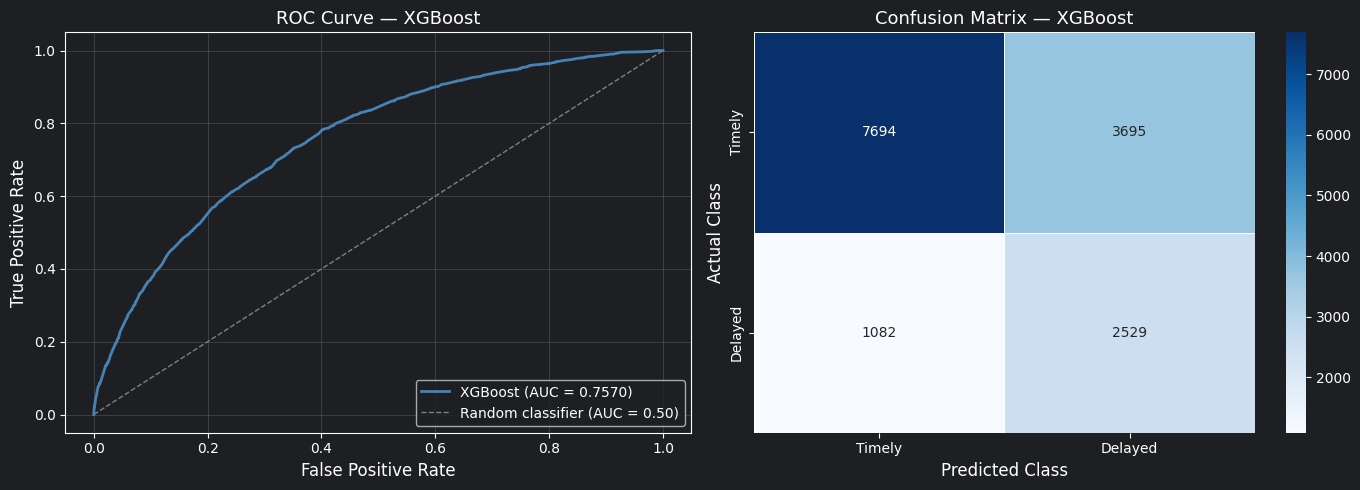

Plot saved: xgb_roc_confusion.png
VARIABLE IMPORTANCE — XGBOOST
Aggregated gain-based importance per predictor
  Specialty                          0.3253  ( 32.5%)
  Posted Billing Group               0.2120  ( 21.2%)
  Facility Type                      0.2110  ( 21.1%)
  Debtor Status                      0.1234  ( 12.3%)
  ICD10 Chapter                      0.1110  ( 11.1%)
  Age Bracket                        0.0173  (  1.7%)


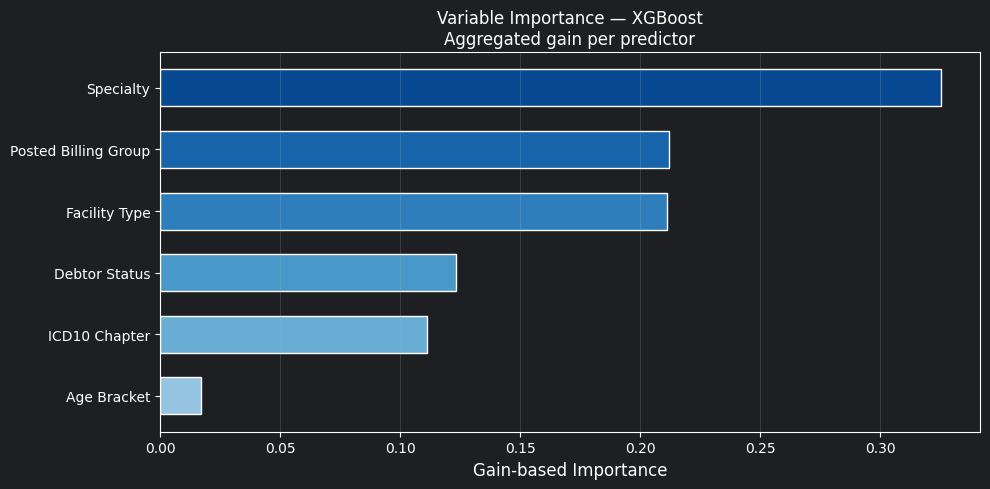

Variable importance plot saved: xgb_variable_importance.png


In [4]:
# ============================================================
# CELL 4: XGBOOST VISUALIZATIONS AND VARIABLE IMPORTANCE
# We produce the same plots we did for Random Forest so
# the comparison in the report is direct and fair.
#
# Functions used:
# plt.subplots() — Creates figure with multiple subplots
# roc_curve() — Returns FPR, TPR, thresholds for ROC plot
# sns.heatmap() — Creates a heatmap from a 2D array
# .feature_importances_ — XGBoost attribute that gives
#   feature importance scores based on gain (how much
#   each feature reduced the loss function across all
#   splits where it was used)
# ============================================================

figures_path = r'C:\2026\MedicalBillingResearch\outputs\figures'

# ── Plot: ROC Curve and Confusion Matrix ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# subplots(1, 2) creates 1 row and 2 columns of plots
# figsize=(14, 5) sets width=14 inches, height=5 inches
# axes is an array of subplot objects — axes[0] and axes[1]

# Left subplot: ROC Curve
fpr, tpr, _ = roc_curve(y_test_enc, y_pred_proba)
# roc_curve returns three arrays:
#   fpr — false positive rates at each threshold
#   tpr — true positive rates at each threshold
#   _ — thresholds (we don't need them, _ is a convention
#       meaning "ignore this value")

axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'XGBoost (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='grey', lw=1,
             linestyle='--',
             label='Random classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — XGBoost', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right subplot: Confusion Matrix Heatmap
cm_labels = ['Timely', 'Delayed']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            ax=axes[1], cbar=True, linewidths=0.5)
# annot=True — show the numbers inside each cell
# fmt='d' — format numbers as integers (no decimals)
# cmap='Blues' — use the Blues color palette
axes[1].set_xlabel('Predicted Class', fontsize=12)
axes[1].set_ylabel('Actual Class', fontsize=12)
axes[1].set_title('Confusion Matrix — XGBoost', fontsize=13)

plt.tight_layout()
plt.savefig(f'{figures_path}\\xgb_roc_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: xgb_roc_confusion.png")

# ── Variable Importance ───────────────────────────────────
# .feature_importances_ gives us a numpy array of importance
# scores, one per encoded feature, summing to 1.0
importance_df = pd.DataFrame({
    'Feature':    X_train_enc.columns,
    'Importance': xgb_model.feature_importances_
})

# Aggregate from encoded column level to original variable
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col  # Age Bracket has no prefix

importance_df['Original Variable'] = (
    importance_df['Feature'].apply(get_original_variable)
)

# .groupby() groups rows by a column value
# .sum() adds up the importance values within each group
var_importance = (
    importance_df.groupby('Original Variable')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("=" * 60)
print("VARIABLE IMPORTANCE — XGBOOST")
print("Aggregated gain-based importance per predictor")
print("=" * 60)
total_imp = var_importance['Importance'].sum()
for _, row in var_importance.iterrows():
    pct = row['Importance'] / total_imp * 100
    print(f"  {row['Original Variable']:<30} "
          f"{row['Importance']:>10.4f}  ({pct:>5.1f}%)")

# Plot variable importance
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(var_importance))
)[::-1]

ax.barh(var_importance['Original Variable'],
        var_importance['Importance'],
        color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Gain-based Importance', fontsize=12)
ax.set_title('Variable Importance — XGBoost\n'
             'Aggregated gain per predictor',
             fontsize=12)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{figures_path}\\xgb_variable_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Variable importance plot saved: xgb_variable_importance.png")

In [5]:
# ============================================================
# CELL 5: SAVE XGBOOST RESULTS
# We save the metrics, predictions and variable importance
# for inclusion in the model comparison and report.
#
# Functions used:
# json.dump() — Writes a Python dictionary to a JSON file
# .to_csv() — Saves a DataFrame to a CSV file
# ============================================================

import json

# ── Save metrics dictionary ───────────────────────────────
xgb_results = {
    'model':             'XGBoost',
    'n_estimators':      500,
    'learning_rate':     0.1,
    'max_depth':         6,
    'scale_pos_weight':  round(scale_pos_weight, 4),
    'accuracy':          round(accuracy, 4),
    'auc':               round(auc, 4),
    'f1_delayed':        round(f1_delayed, 4),
    'precision_delayed': round(precision_delayed, 4),
    'recall_delayed':    round(recall_delayed, 4),
    'true_negatives':    int(cm[0,0]),
    'false_positives':   int(cm[0,1]),
    'false_negatives':   int(cm[1,0]),
    'true_positives':    int(cm[1,1]),
}

with open(
    r'C:\2026\MedicalBillingResearch\models\xgb_metrics.json', 'w'
) as f:
    json.dump(xgb_results, f, indent=4)

# 'w' opens the file in write mode
# json.dump writes the dictionary to the file
# indent=4 formats the JSON with 4-space indentation for readability

# ── Save predictions for model comparison ─────────────────
pd.DataFrame({
    'y_true':       y_test_enc,
    'y_pred':       y_pred,
    'y_pred_proba': y_pred_proba
}).to_csv(
    r'C:\2026\MedicalBillingResearch\models\xgb_predictions.csv',
    index=False
)

# ── Save variable importance ──────────────────────────────
var_importance.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\xgb_variable_importance.csv',
    index=False
)

print("=" * 60)
print("XGBOOST RESULTS SAVED")
print("=" * 60)
print(f"\n  Metrics saved     : models/xgb_metrics.json")
print(f"  Predictions saved : models/xgb_predictions.csv")
print(f"  Importance saved  : models/xgb_variable_importance.csv")
print(f"\n  Summary:")
for key, val in xgb_results.items():
    print(f"    {key:<22} : {val}")

# ── Final comparison verdict ──────────────────────────────
print(f"\n{'=' * 60}")
print("MODEL SELECTION DECISION — UNCHANGED")
print("=" * 60)
print("""
  XGBoost did not produce meaningful improvement over Random Forest.
  Differences are within rounding noise on the primary metrics.

  Performance summary:
    AUC      : RF 0.7550 vs XGB 0.7570 (difference: 0.002)
    F1       : RF 0.5144 vs XGB 0.5143 (difference: 0.0001)
    Accuracy : RF 68.62% vs XGB 68.15% (RF slightly higher)
    Recall   : RF 69.04% vs XGB 70.04% (XGB slightly higher)

  Random Forest remains the selected model because:
  1. F1 scores are essentially tied — XGBoost loses by 0.0001
  2. Random Forest is more interpretable than XGBoost
  3. Random Forest has higher accuracy and precision
  4. The 0.002 AUC improvement is not meaningful

  XGBoost is reported as the fourth model tested to demonstrate
  completeness in the modelling approaches considered.
""")

print(f"  XGBoost notebook — COMPLETE")

XGBOOST RESULTS SAVED

  Metrics saved     : models/xgb_metrics.json
  Predictions saved : models/xgb_predictions.csv
  Importance saved  : models/xgb_variable_importance.csv

  Summary:
    model                  : XGBoost
    n_estimators           : 500
    learning_rate          : 0.1
    max_depth              : 6
    scale_pos_weight       : 3.1533
    accuracy               : 0.6815
    auc                    : 0.757
    f1_delayed             : 0.5143
    precision_delayed      : 0.4063
    recall_delayed         : 0.7004
    true_negatives         : 7694
    false_positives        : 3695
    false_negatives        : 1082
    true_positives         : 2529

MODEL SELECTION DECISION — UNCHANGED

  XGBoost did not produce meaningful improvement over Random Forest.
  Differences are within rounding noise on the primary metrics.

  Performance summary:
    AUC      : RF 0.7550 vs XGB 0.7570 (difference: 0.002)
    F1       : RF 0.5144 vs XGB 0.5143 (difference: 0.0001)
    Accuracy 

XGBOOST VARIABLE IMPORTANCE - STANDALONE PLOT
   Original Variable  Importance
           Specialty    0.325307
Posted Billing Group    0.211952
       Facility Type    0.211010
       Debtor Status    0.123445
       ICD10 Chapter    0.111022
         Age Bracket    0.017264


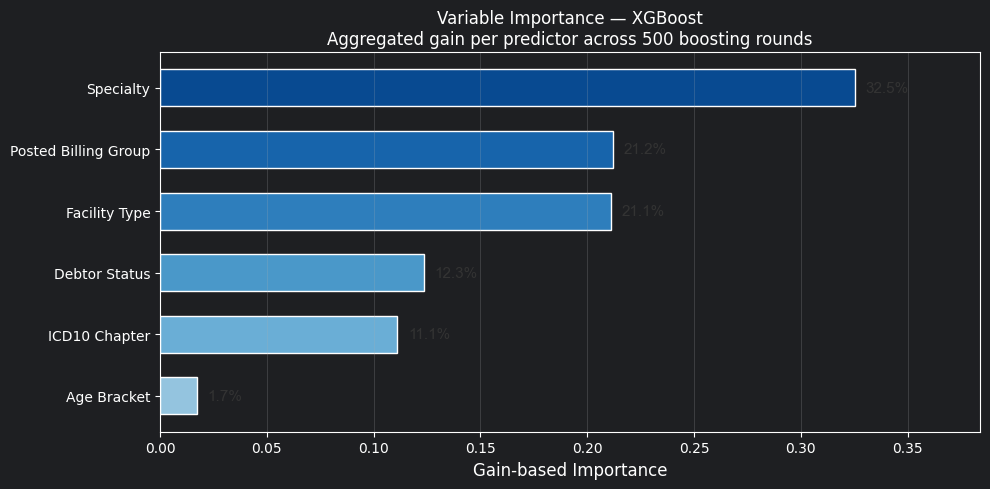


Plot saved: xgb_variable_importance.png


In [1]:
# ============================================================
# QUICK FIX: STANDALONE XGBOOST VARIABLE IMPORTANCE PLOT
# We already have the importance values saved in
# models/xgb_variable_importance.csv. We just need to
# generate the dedicated plot for the XGBoost section.
#
# Functions used:
# pd.read_csv() — Reload saved importance values
# plt.subplots() — Create figure with axes
# .barh() — Horizontal bar chart
# .invert_yaxis() — Flip y-axis to put highest at top
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load saved XGBoost variable importance
xgb_imp = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\xgb_variable_importance.csv'
)

print("=" * 60)
print("XGBOOST VARIABLE IMPORTANCE - STANDALONE PLOT")
print("=" * 60)
print(xgb_imp.to_string(index=False))

# Generate the plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(xgb_imp))
)[::-1]

ax.barh(
    xgb_imp['Original Variable'],
    xgb_imp['Importance'],
    color=colors, edgecolor='white', height=0.6
)

# Add percentage labels
total_imp = xgb_imp['Importance'].sum()
for i, (_, row) in enumerate(xgb_imp.iterrows()):
    pct = row['Importance'] / total_imp * 100
    ax.text(
        row['Importance'] + 0.005, i,
        f'{pct:.1f}%',
        va='center', ha='left',
        fontfamily='Arial', fontsize=11, color='#333333'
    )

ax.set_xlabel('Gain-based Importance', fontsize=12)
ax.set_title(
    'Variable Importance — XGBoost\n'
    'Aggregated gain per predictor across 500 boosting rounds',
    fontsize=12
)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, xgb_imp['Importance'].max() * 1.18)

plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\xgb_variable_importance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nPlot saved: xgb_variable_importance.png")